# Exploring Penguin Colonies in SAR Imagery

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import xarray as xr
from pystac_client import Client
from odc.stac import load, configure_s3_access
from odc.geo import BoundingBox
from shapely.geometry import Point, box
import geopandas as gpd
import math
import datetime
import numpy as np
import planetary_computer as pc
import xarray as xr
from IPython.display import display
from pystac_client import Client
from odc.stac import configure_rio, stac_load

import numpy as np
import rasterio
import sys
sys.path.insert(1,'./src/')
from lee_sigma_improved_xr import lee_sigma_improved_xr, lee_sigma_improved_xr_multitime  # import the function we wrote


def bbox_from_point(lat, lon, radius_km):
    delta_lat = radius_km / 111.32
    delta_lon = radius_km / (111.32 * math.cos(math.radians(lat)))
    
    min_lat = lat - delta_lat
    max_lat = lat + delta_lat
    min_lon = lon - delta_lon
    max_lon = lon + delta_lon
    
    return BoundingBox(min_lon, min_lat, max_lon, max_lat,crs="EPSG:4326")

In [4]:
# Set up the query
catalog = "https://explorer.dev.dea.ga.gov.au/stac"
stac_client = Client.open(catalog)
configure_s3_access(cloud_defaults=True, aws_unsigned=True)

In [11]:
penguin_lat = -77.451 #-68.5381613
penguin_lon =  169.272
penguin_date = "2024-01-15"
start = datetime.date(2024, 1, 1)
end = datetime.date(2024, 2, 1)

In [12]:
penguin_bbox = bbox_from_point(penguin_lat,	penguin_lon, 1)
#penguin_bbox = BoundingBox(math.floor(penguin_lon*10)/10, math.floor(penguin_lat*10)/10, math.ceil(penguin_lon*10)/10, math.ceil(penguin_lat*10)/10 )
#penguin_bbox.explore()

### Access Sentinel-1

In [13]:
penguin_items = stac_client.search(
    datetime=f"{start}/{end}",
    collections=["ga_s1_nrb_iw_vv_vh_0","ga_s1_nrb_iw_hh_hv_0",'ga_s1_nrb_iw_hh_0'],
    bbox = penguin_bbox.bbox
).item_collection()
print(f"Found {len(penguin_items)} items")

Found 6 items


In [14]:
# Assets to load
assets_to_load = ["HH_gamma0","number_of_looks"]

# CRS and resolution
output_crs = "epsg:3031"
output_res = 20 # 20m is the native resolution of the data. Here, we resample to 400m to save memory

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

In [15]:
# Load the data
ds = load(
    items=penguin_items,
    bands=assets_to_load,
    intersects = penguin_bbox.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby=groupy_by_operation,
    chunks={},
)

# Find the closest time in the dataset
time_index = ds.time.values
closest_idx = np.argmin(np.abs(time_index -  np.datetime64(penguin_date)))
closest_time = time_index[closest_idx]
ds_TS = ds
ds = ds.sel(time=closest_time)

In [77]:
ds

<xarray.Dataset> Size: 119kB
Dimensions:          (y: 121, x: 121)
Coordinates:
  * y                (y) float64 968B 4.883e+05 4.882e+05 ... 4.859e+05
  * x                (x) float64 968B 2.306e+06 2.306e+06 ... 2.309e+06
    spatial_ref      int32 4B 3031
    time             datetime64[ns] 8B 2024-12-11T22:27:22.812183
Data variables:
    HH_gamma0        (y, x) float32 59kB dask.array<chunksize=(121, 121), meta=np.ndarray>
    number_of_looks  (y, x) float32 59kB dask.array<chunksize=(121, 121), meta=np.ndarray>

In [16]:
ds.compute()

<xarray.Dataset> Size: 111kB
Dimensions:          (y: 117, x: 117)
Coordinates:
  * y                (y) float64 936B -1.344e+06 -1.344e+06 ... -1.346e+06
  * x                (x) float64 936B 2.536e+05 2.536e+05 ... 2.559e+05 2.56e+05
    spatial_ref      int32 4B 3031
    time             datetime64[ns] 8B 2024-01-15T12:48:00.950648
Data variables:
    HH_gamma0        (y, x) float32 55kB 0.2698 0.3466 ... 0.003062 0.004883
    number_of_looks  (y, x) float32 55kB 7.547 7.437 7.476 ... 7.751 7.751 7.751

### Access Sentinel-2

In [17]:
stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

search = stac.search(
    collections=["sentinel-2-l2a"],
    bbox= penguin_bbox.bbox,
    datetime=f"{start}/{end}",#f"{penguin_date}",
)
S2_items = search.item_collection()
print(f"Found {len(S2_items)} items")

Found 42 items


In [18]:
# Assets to load
assets_to_load = ["B04","B03","B02"]

# CRS and resolution
output_crs = "epsg:3031"
output_res = 10 # 20m is the native resolution of the data. Here, we resample to 400m to save memory

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

In [19]:
S2_items = pc.sign(S2_items)
# Load the data
ds_S2 = load(
    items=S2_items,
    bands=assets_to_load,
    intersects = penguin_bbox.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby=groupy_by_operation,
    chunks={}
)

In [21]:
ds_S2.compute()
# Reproject to match the reference dataset
#ds_S2 = ds_S2.rio.reproject_match(ds)


<xarray.Dataset> Size: 8MB
Dimensions:      (y: 232, x: 232, time: 13)
Coordinates:
  * y            (y) float64 2kB -1.344e+06 -1.344e+06 ... -1.346e+06 -1.346e+06
  * x            (x) float64 2kB 2.536e+05 2.536e+05 ... 2.559e+05 2.559e+05
    spatial_ref  int32 4B 3031
  * time         (time) datetime64[ns] 104B 2024-01-02T19:45:19.024000 ... 20...
Data variables:
    B04          (time, y, x) float32 3MB 1.09e+04 1.086e+04 ... 9.92e+03
    B03          (time, y, x) float32 3MB 1.128e+04 1.126e+04 ... 9.752e+03
    B02          (time, y, x) float32 3MB 1.188e+04 1.18e+04 ... 9.728e+03

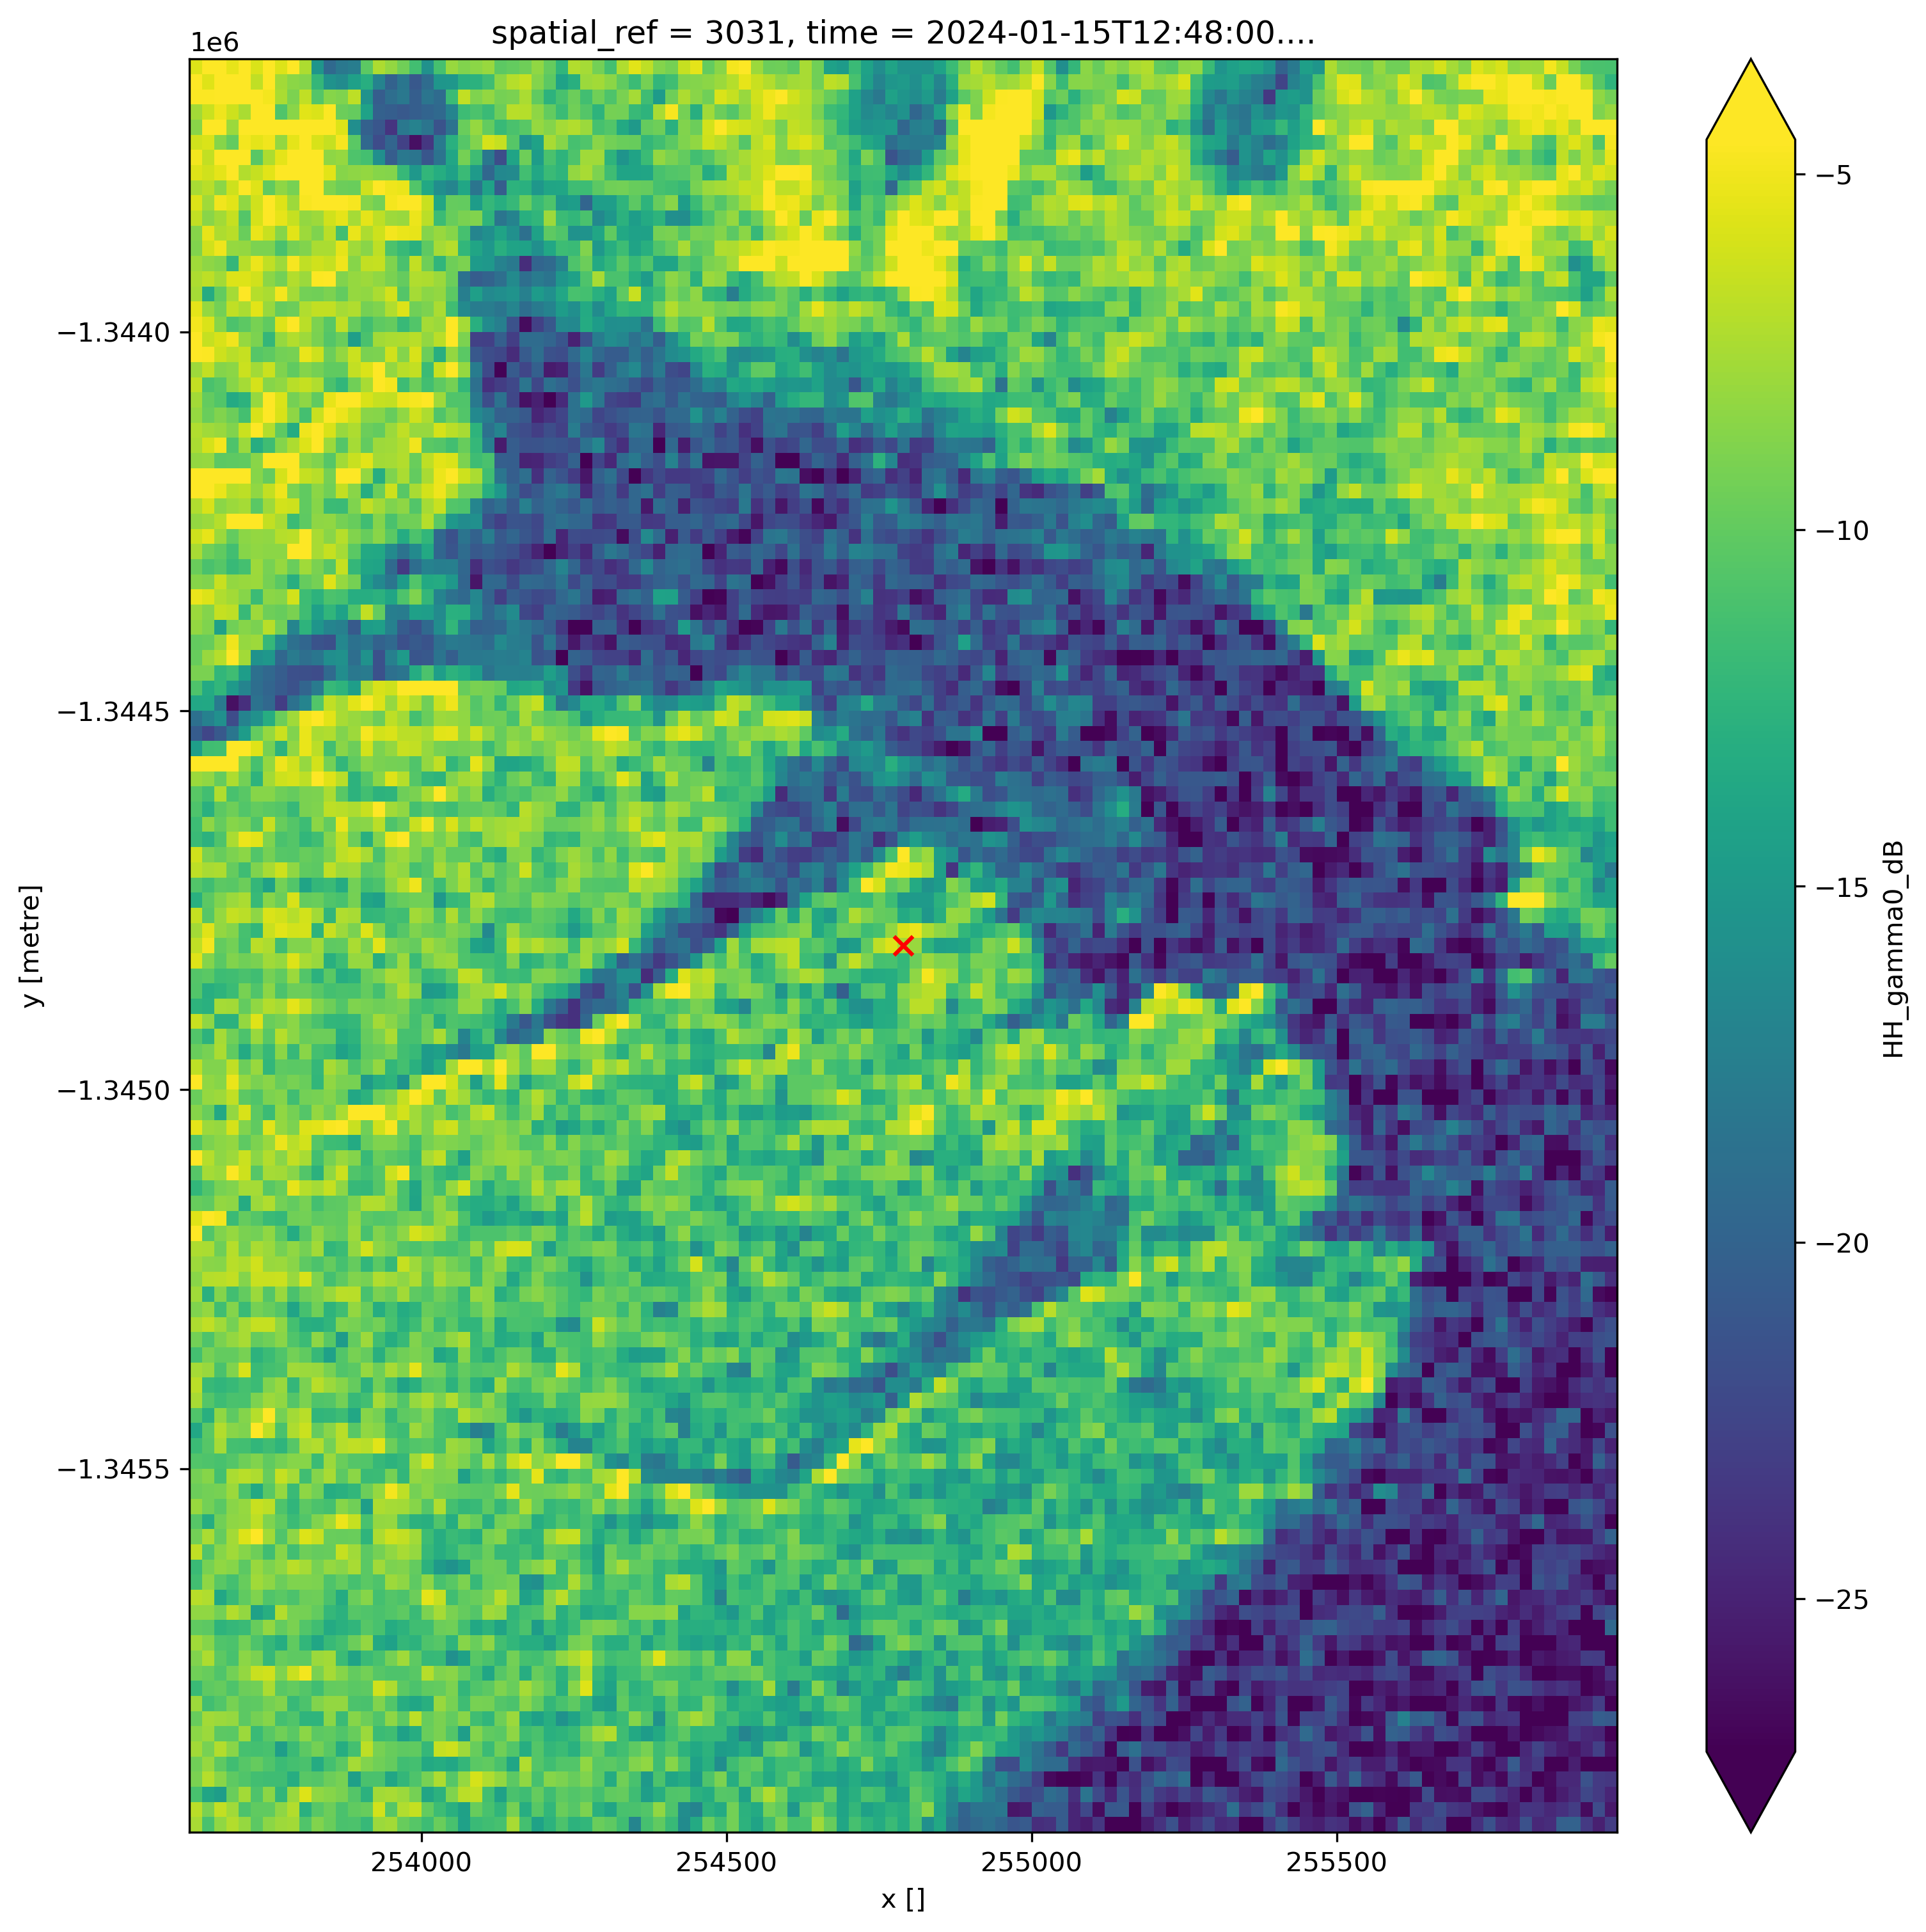

In [22]:
# Quickly plot to visualise the data
plt.figure(figsize=(12, 12), dpi=300)
ds["HH_gamma0_dB"] = 10*np.log10(ds["HH_gamma0"] + 1e-12)
ds["HH_gamma0_dB"].plot(robust = True)
x = ds["HH_gamma0_dB"]["x"].values
y = ds["HH_gamma0_dB"]["y"].values

# Compute the center point
x_center = (x.min() + x.max()) / 2
y_center = (y.min() + y.max()) / 2

# Plot the point in the center
plt.scatter(x_center, y_center, color="red", s=50, marker="x")
plt.show()

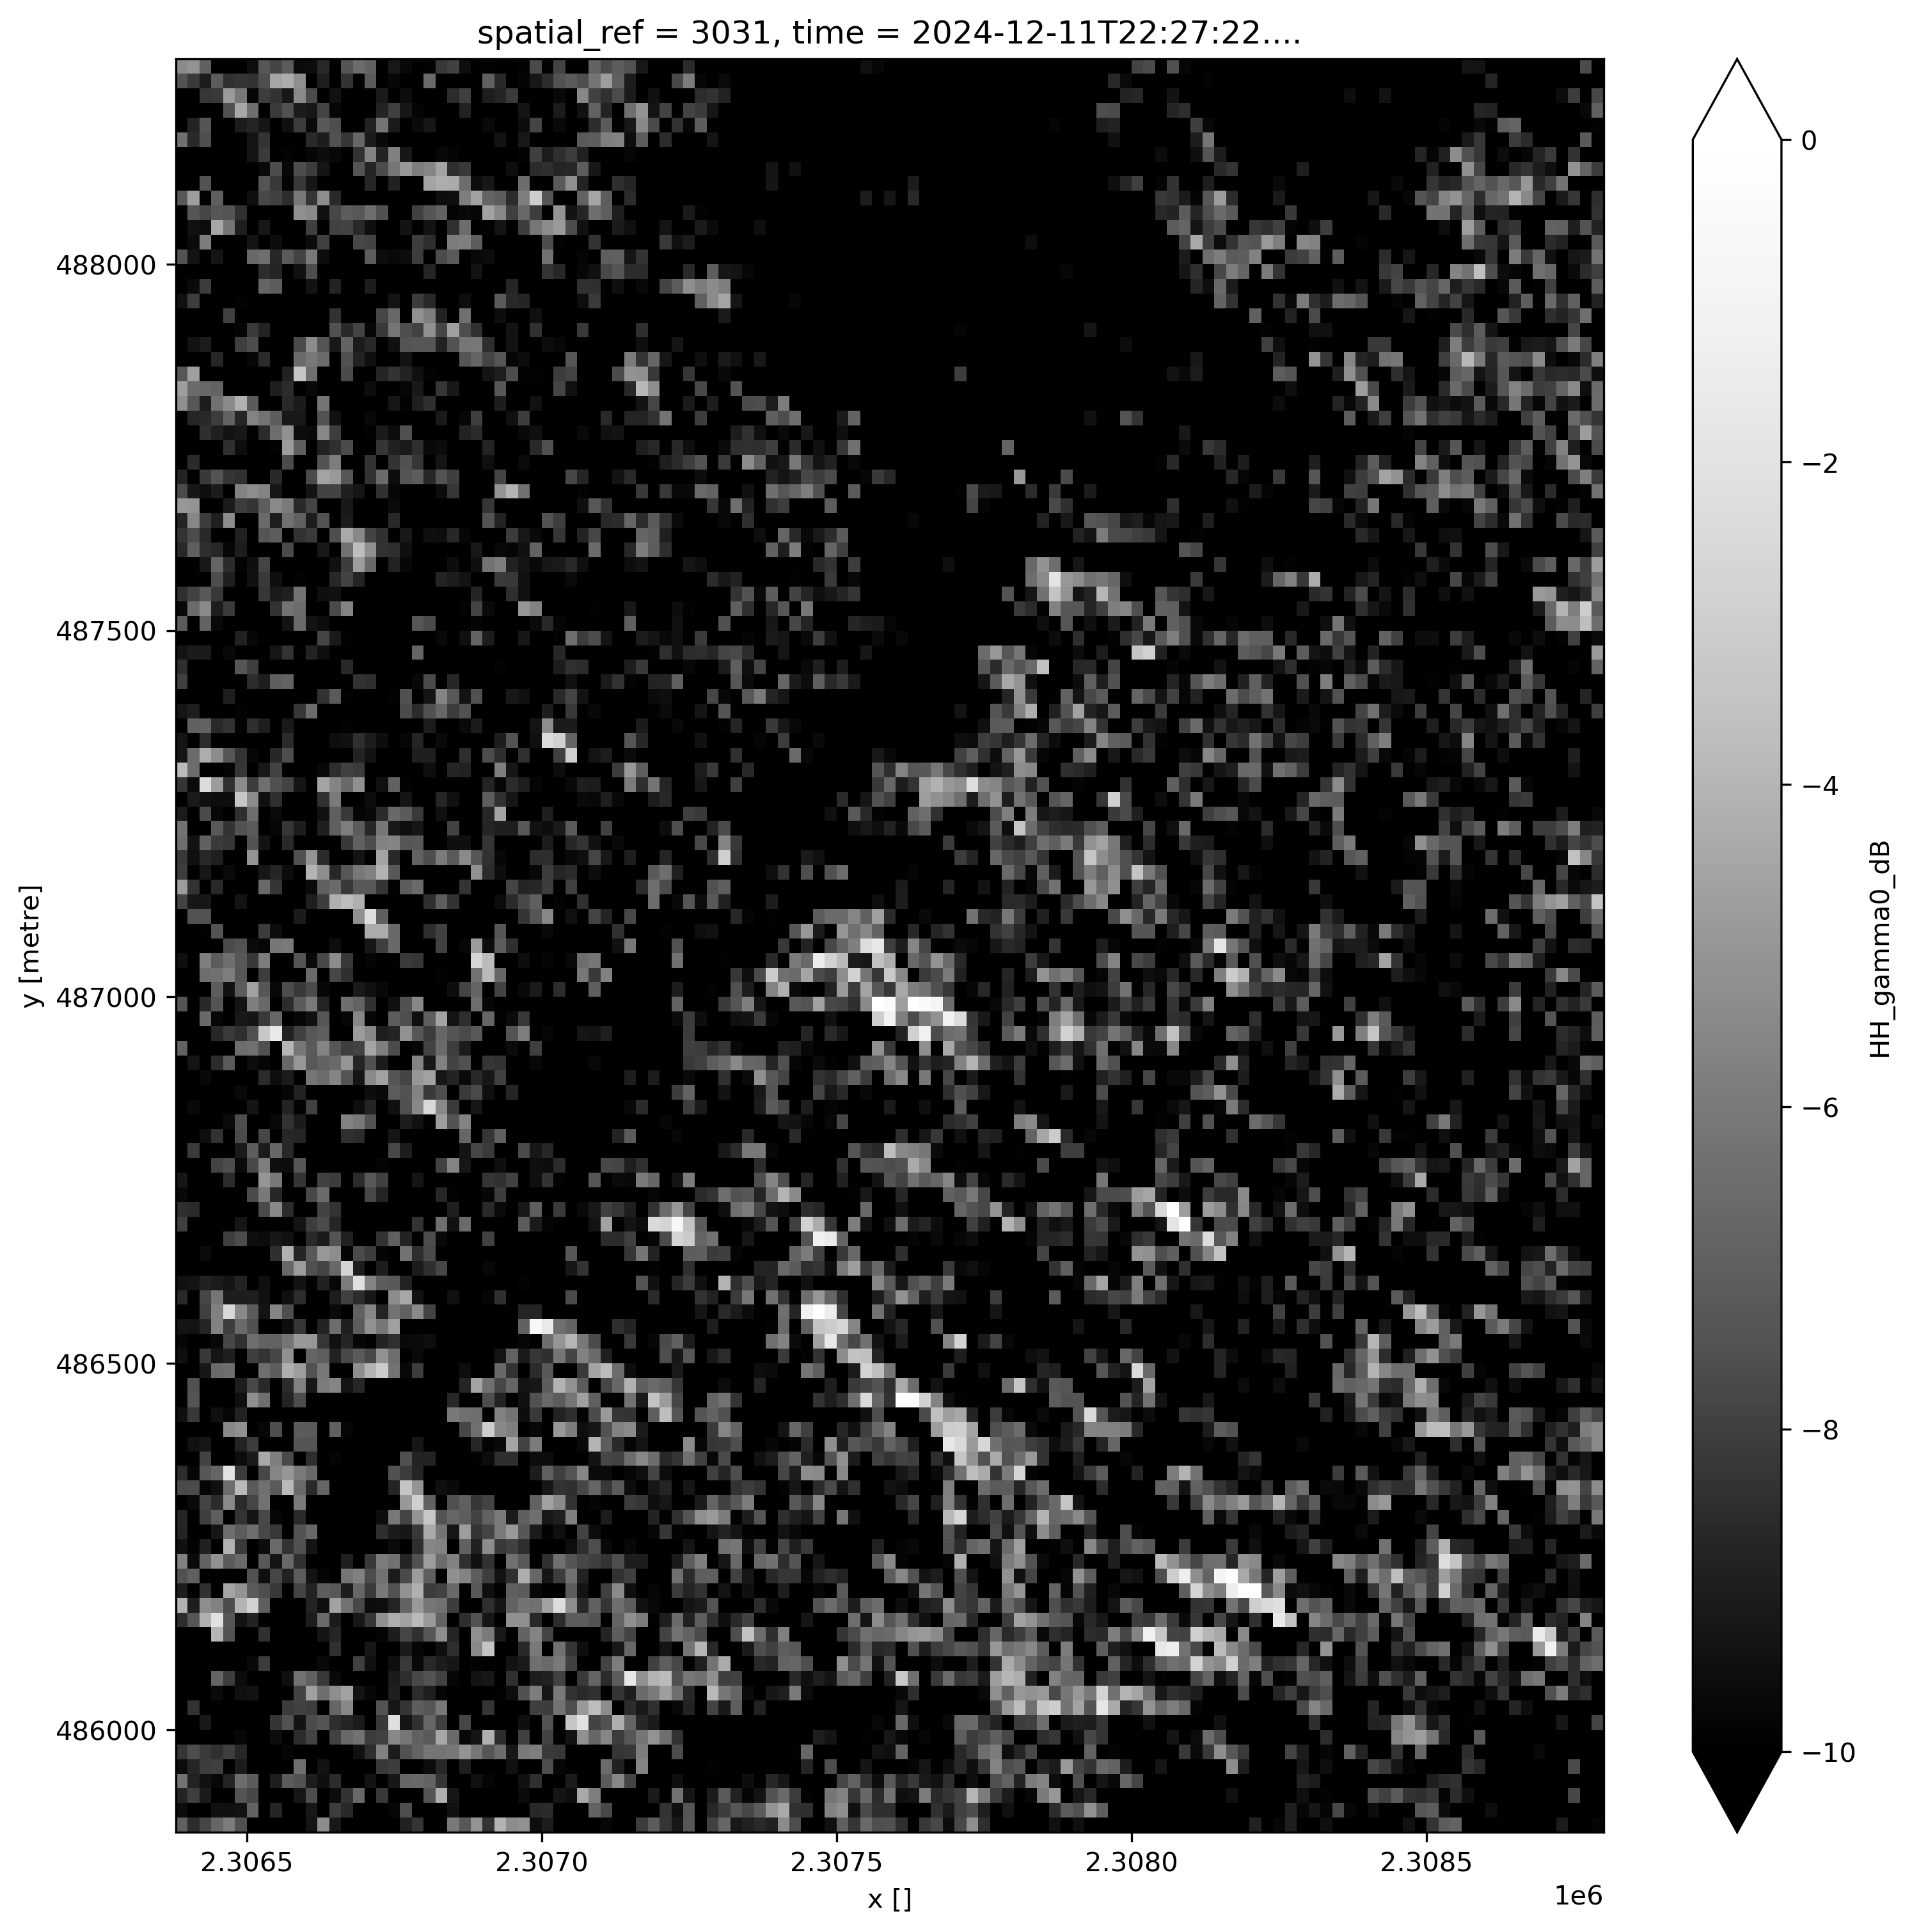

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Compute gamma0 in dB safely
gamma0 = ds["HH_gamma0"]  # ensure no zeros or negatives
ds["HH_gamma0_dB"] = 10 * np.log10(gamma0)

# Plot
plt.figure(figsize=(12, 12), dpi=300)
ds["HH_gamma0_dB"].plot(vmin=-10, vmax=0, cmap="Greys_r", robust=True)
plt.show()


In [81]:
ds_filtered = lee_sigma_improved_xr(
    ds, 
    'HH_gamma0',
    'number_of_looks', 
    data_type = 'intensity',
    win=(9, 9)
)
ds_filtered_dB = 10 * np.log10(ds_filtered)

/home/ubuntu/miniforge3/envs/pyrat/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


/home/ubuntu/miniforge3/envs/pyrat/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


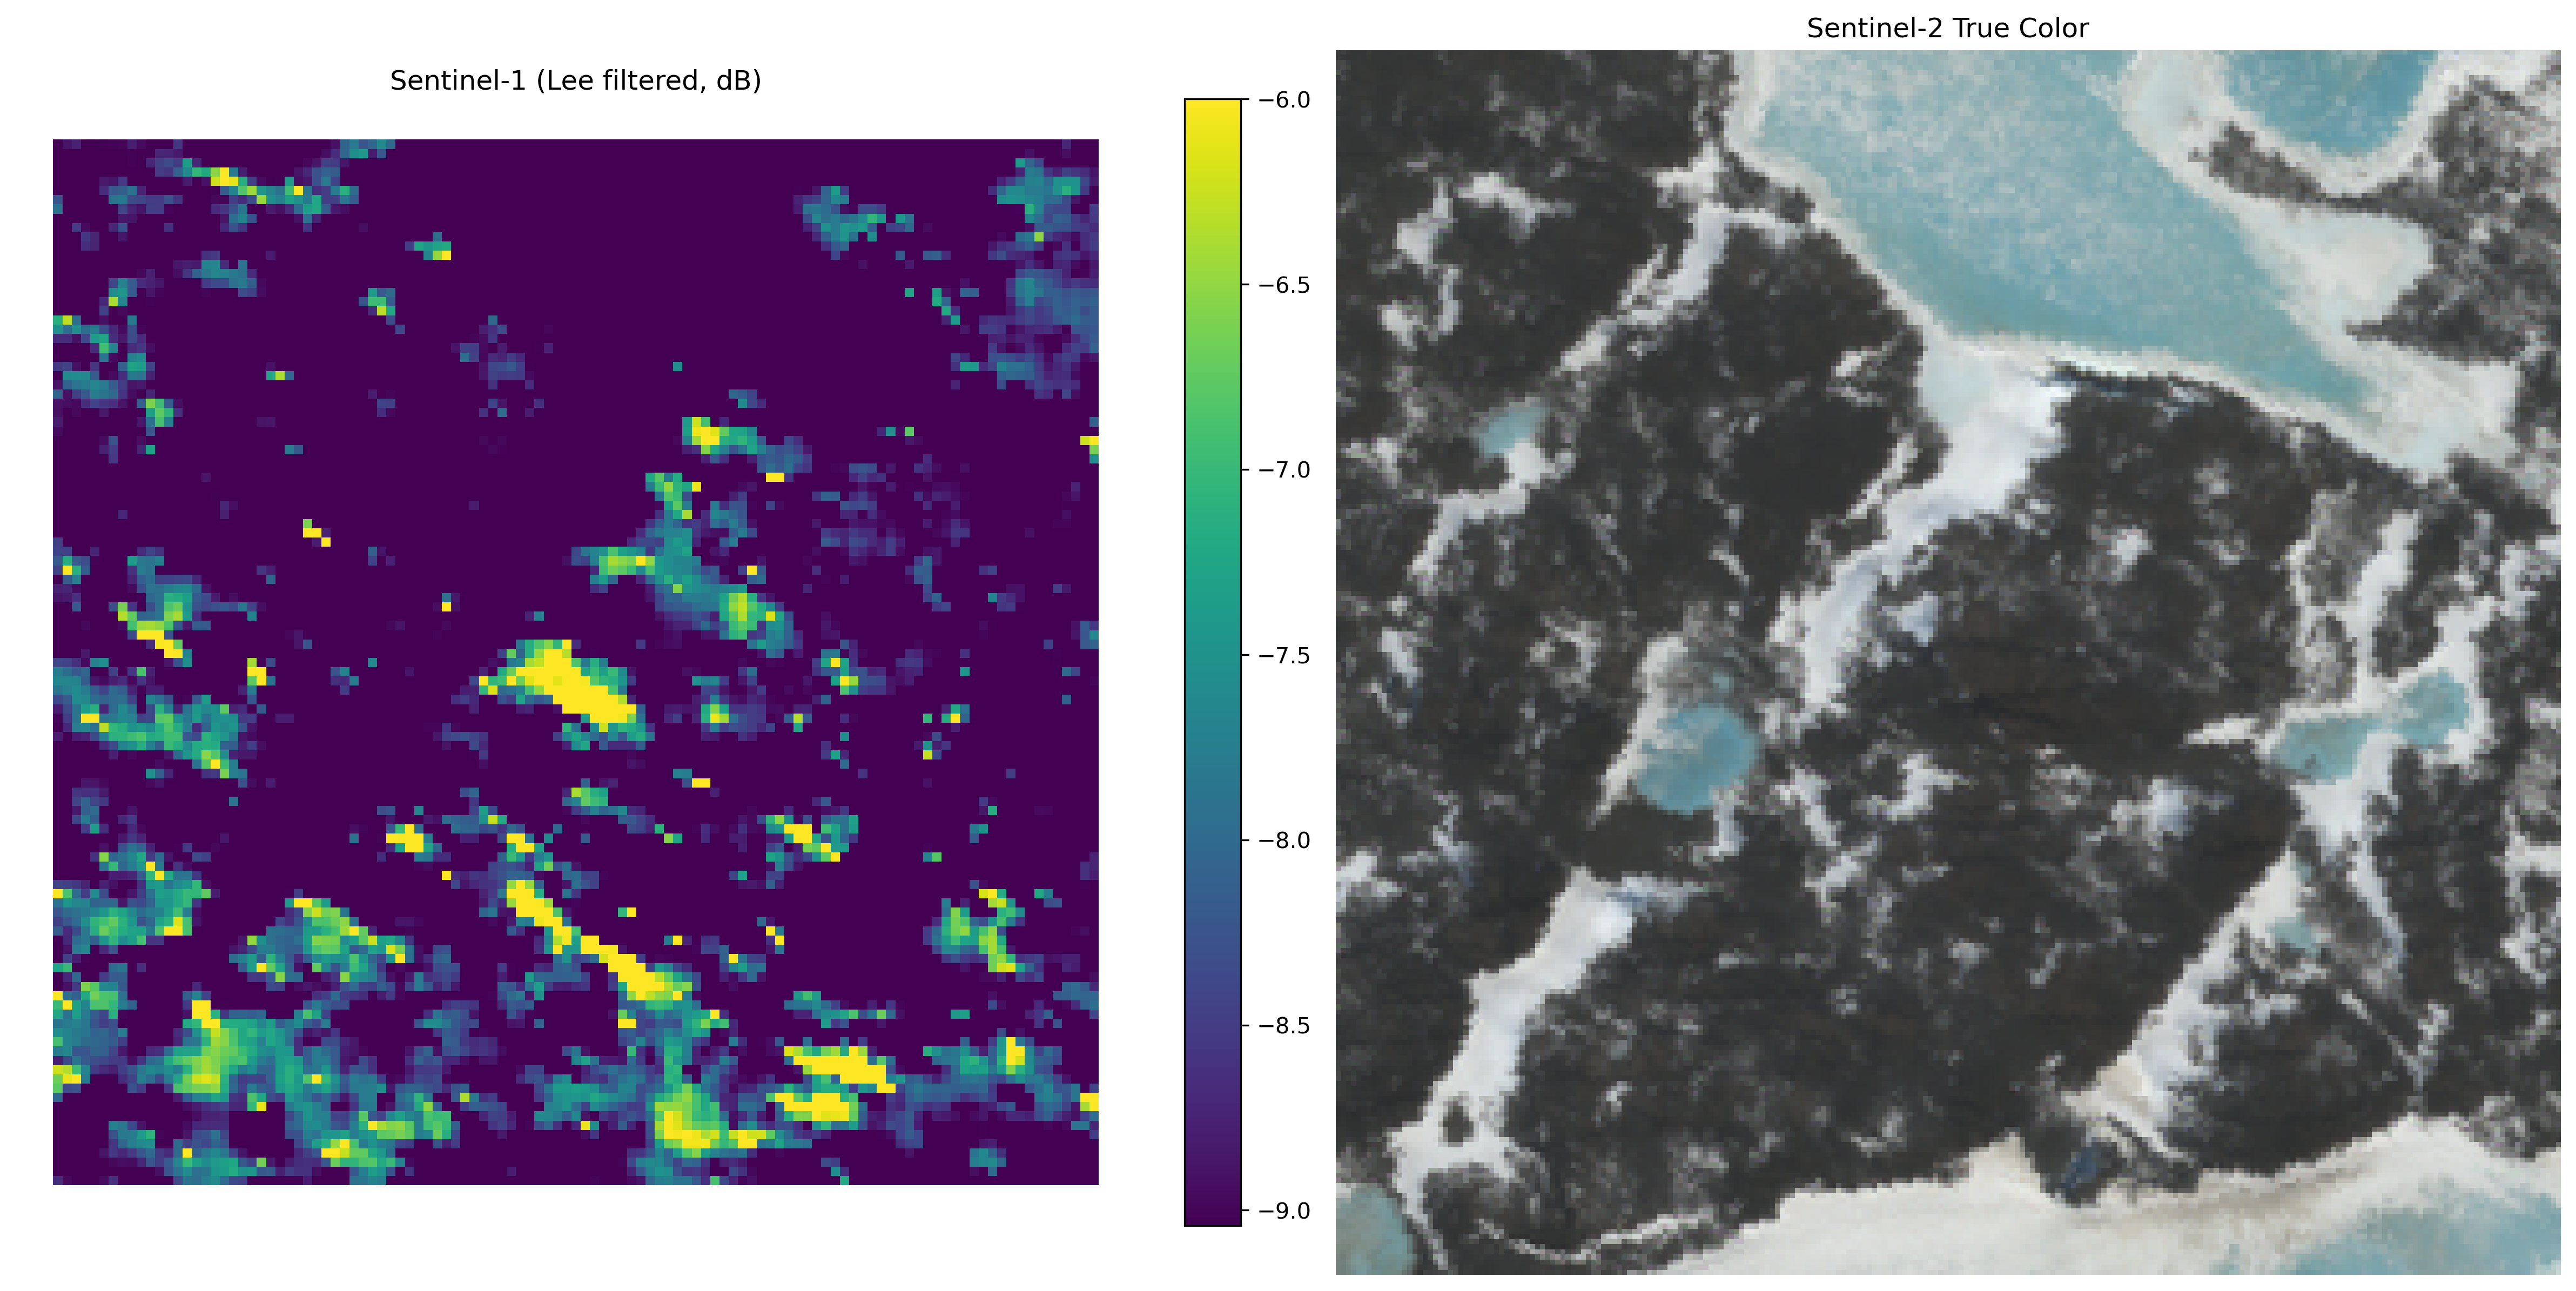

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# --- Build Sentinel-2 True Color composite (B04=R, B03=G, B02=B) ---
rgb_S2 = np.dstack([
    ds_S2["B04"].isel(time=0).values,
    ds_S2["B03"].isel(time=0).values,
    ds_S2["B02"].isel(time=0).values,
])

# Optional normalization (Sentinel-2 reflectance is often 0–10000)
rgb_S2 = np.clip(rgb_S2 / np.nanmax(rgb_S2), 0, 1)

# --- Compute robust min/max for Sentinel-1 ---
vmin, vmax = np.nanpercentile(ds_filtered_dB, [10, 85])

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=300)

# Sentinel-1 (Lee filtered, dB) with robust scaling
#im1 = ds_filtered['HH_gamma0_filtered_dB'].plot(ax=axes[0], vmin = -18, vmax = -10)
im1 = axes[0].imshow(ds_filtered_dB, vmin = -6, vmax = vmax)
axes[0].set_title("Sentinel-1 (Lee filtered, dB)")
axes[0].set_axis_off()
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Sentinel-2 (True Color)
axes[1].imshow(rgb_S2)
axes[1].set_title("Sentinel-2 True Color")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


In [83]:
ds_TS.compute()

<xarray.Dataset> Size: 470kB
Dimensions:          (y: 121, x: 121, time: 4)
Coordinates:
  * y                (y) float64 968B 4.883e+05 4.882e+05 ... 4.859e+05
  * x                (x) float64 968B 2.306e+06 2.306e+06 ... 2.309e+06
    spatial_ref      int32 4B 3031
  * time             (time) datetime64[ns] 32B 2024-12-11T22:27:22.812183 ......
Data variables:
    HH_gamma0        (time, y, x) float32 234kB 0.2881 0.3066 ... 0.04232
    number_of_looks  (time, y, x) float32 234kB 6.069 6.598 7.041 ... 7.843 7.97

In [84]:
filtered_ds = lee_sigma_improved_xr_multitime(
    ds_TS,
    band_name="HH_gamma0",
    nlooks="number_of_looks",
    win=(9, 9),
    sigma=0.9,
    perc=0.02,
    data_type="intensity",
    verbose=True,
)
print(filtered_ds)

/home/ubuntu/sentinel-1-hackathon/src/lee_sigma_improved_xr.py:350: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t in range(ds.dims.get("time", 1)):
<frozen _collections_abc>:807: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/home/ubuntu/sentinel-1-hackathon/src/lee_sigma_improved_xr.py:352: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Processing time index {t+1}/{ds.dims['time'

Processing time index 1/4
Rounded looks unique values (count=20): [ 3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5  9.   9.5
 10.  10.5 11.  11.5 12.  12.5]
Precomputation complete: bounds & newsig for rounded looks.
Point-target threshold: 0.3457573115825652
Processing time index 2/4
Rounded looks unique values (count=20): [ 3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5  9.   9.5
 10.  10.5 11.  11.5 12.  12.5]
Precomputation complete: bounds & newsig for rounded looks.
Point-target threshold: 0.35402855873107886
Processing time index 3/4
Rounded looks unique values (count=20): [ 3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5  9.   9.5
 10.  10.5 11.  11.5 12.  12.5]
Precomputation complete: bounds & newsig for rounded looks.
Point-target threshold: 0.3687402248382567


Processing time index 4/4
Rounded looks unique values (count=20): [ 3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5  9.   9.5
 10.  10.5 11.  11.5 12.  12.5]
Precomputation complete: bounds & newsig for rounded looks.
Point-target threshold: 0.39297496676444965
<xarray.Dataset> Size: 939kB
Dimensions:                       (y: 121, x: 121, time: 4)
Coordinates:
  * y                             (y) float64 968B 4.883e+05 ... 4.859e+05
  * x                             (x) float64 968B 2.306e+06 ... 2.309e+06
    spatial_ref                   int32 4B 3031
  * time                          (time) datetime64[ns] 32B 2024-12-11T22:27:...
Data variables:
    HH_gamma0                     (time, y, x) float32 234kB dask.array<chunksize=(1, 121, 121), meta=np.ndarray>
    number_of_looks               (time, y, x) float32 234kB dask.array<chunksize=(1, 121, 121), meta=np.ndarray>
    HH_gamma0_lee_sigma_improved  (time, y, x) float64 469kB 0.0 0.0 ... 0.0 0.0


In [85]:
filtered_ds['HH_gamma0_lee_sigma_improved_dB'] = 10 * np.log10(filtered_ds['HH_gamma0_lee_sigma_improved'])

/home/ubuntu/miniforge3/envs/pyrat/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


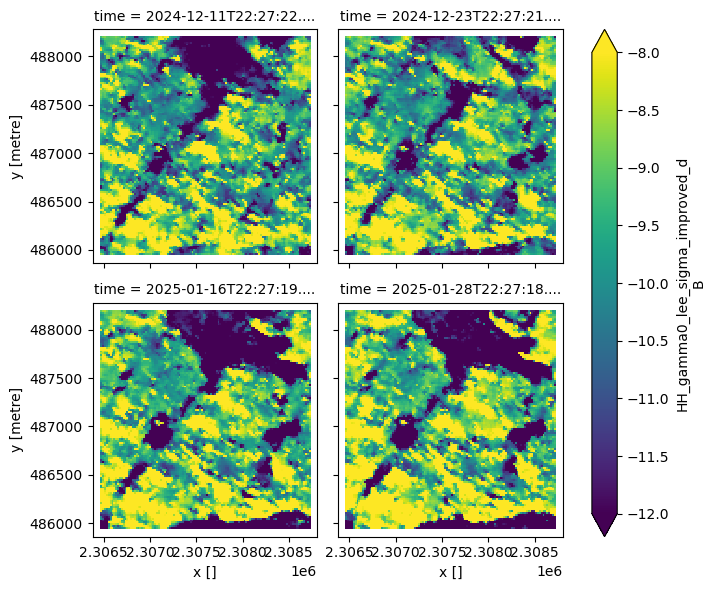

In [101]:
filtered_ds['HH_gamma0_lee_sigma_improved_dB'].plot.imshow(col="time", col_wrap=2, vmin = -12, vmax = -8)

In [87]:
filtered_ds['change'] = filtered_ds['HH_gamma0_lee_sigma_improved_dB'] - filtered_ds['HH_gamma0_lee_sigma_improved_dB'].isel(time = 13)
filtered_ds['change'].plot.imshow(col="time", col_wrap=2, robust = True)

IndexError: index 13 is out of bounds for axis 0 with size 4

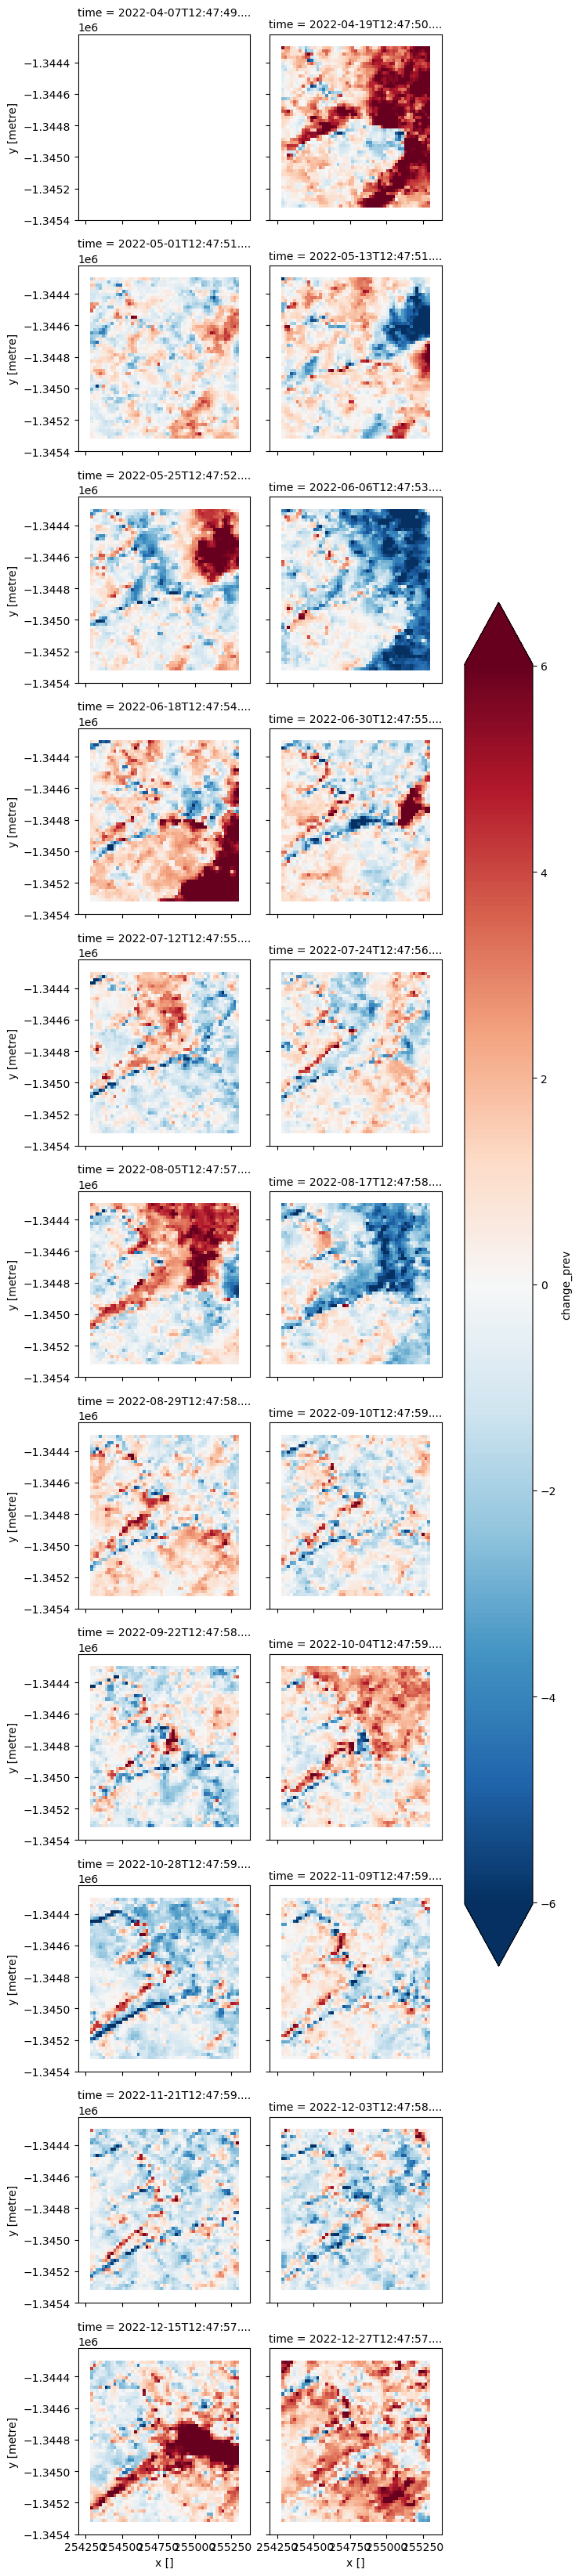

In [ ]:
# Compute change relative to previous time step
filtered_ds['change_prev'] = filtered_ds['HH_gamma0_lee_sigma_improved_dB'].diff(dim='time')

filtered_ds['change_prev'].plot.imshow(
    col="time",
    col_wrap=2,
    robust=True,
    cmap="RdBu_r"  # good for positive/negative changes
)



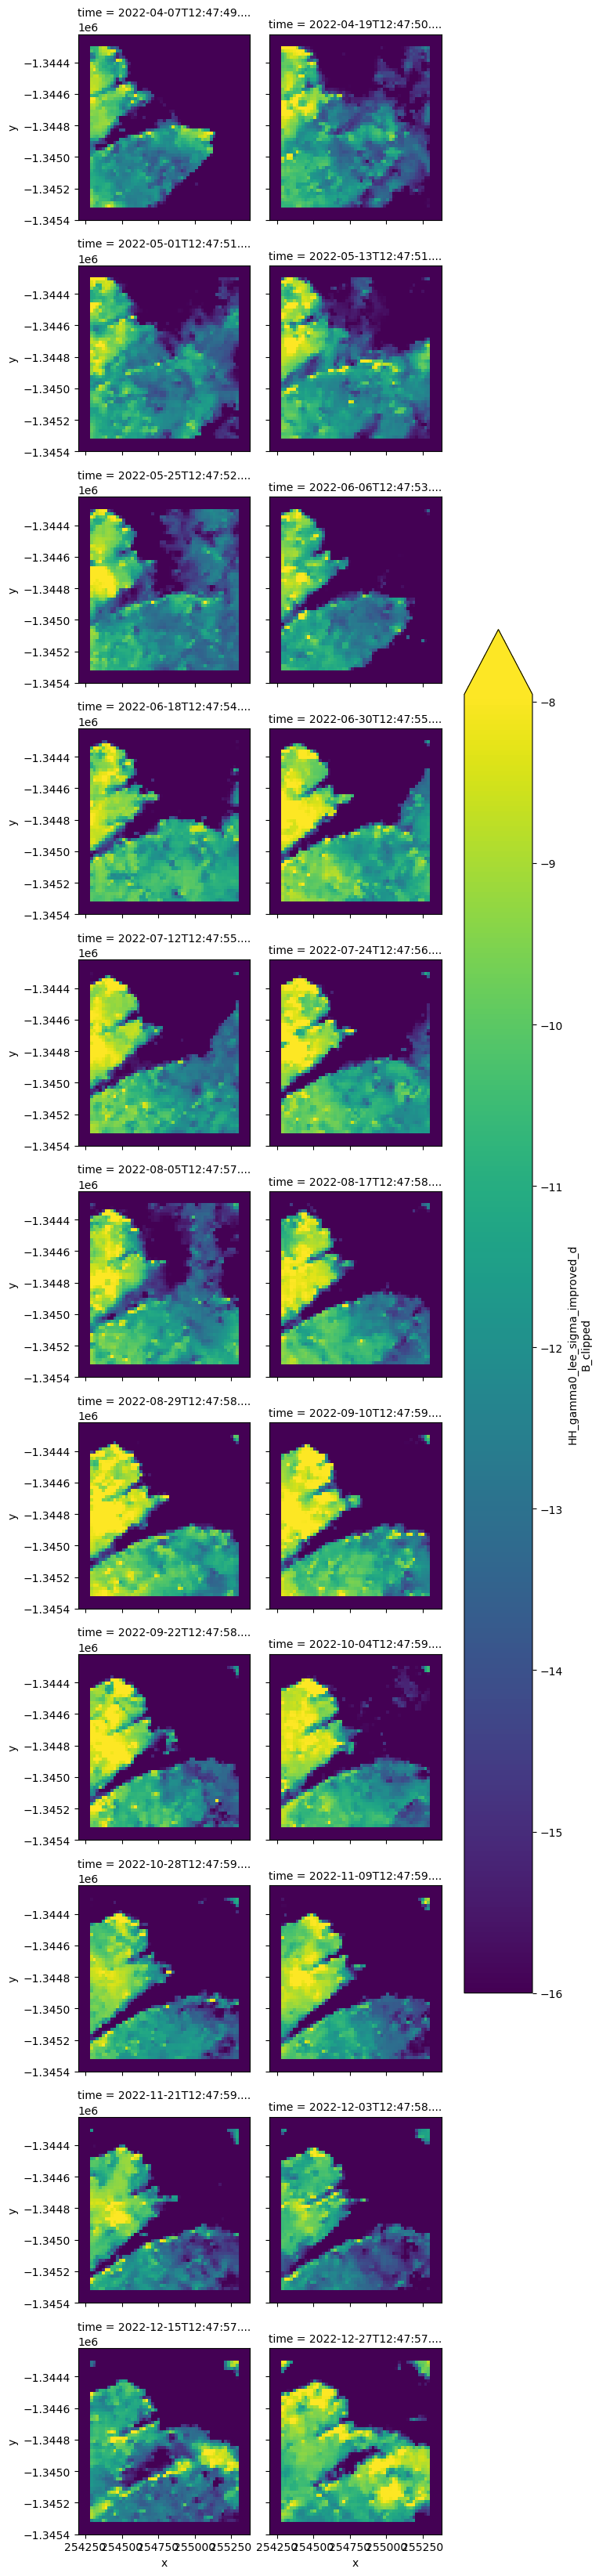

In [ ]:
da = filtered_ds['HH_gamma0_lee_sigma_improved_dB']
# Thresholds
min_val = -16.0
max_val = -4.0

# Clip values
da_clipped = xr.where(da < min_val, min_val, da)       # values below min_val -> min_val
da_clipped = xr.where(da_clipped > max_val, max_val, da_clipped)  # values above max_val -> max_val

# Assign back to dataset if desired
filtered_ds['HH_gamma0_lee_sigma_improved_dB_clipped'] = da_clipped

filtered_ds['HH_gamma0_lee_sigma_improved_dB_clipped'].plot.imshow(col="time", col_wrap=2, robust = True)

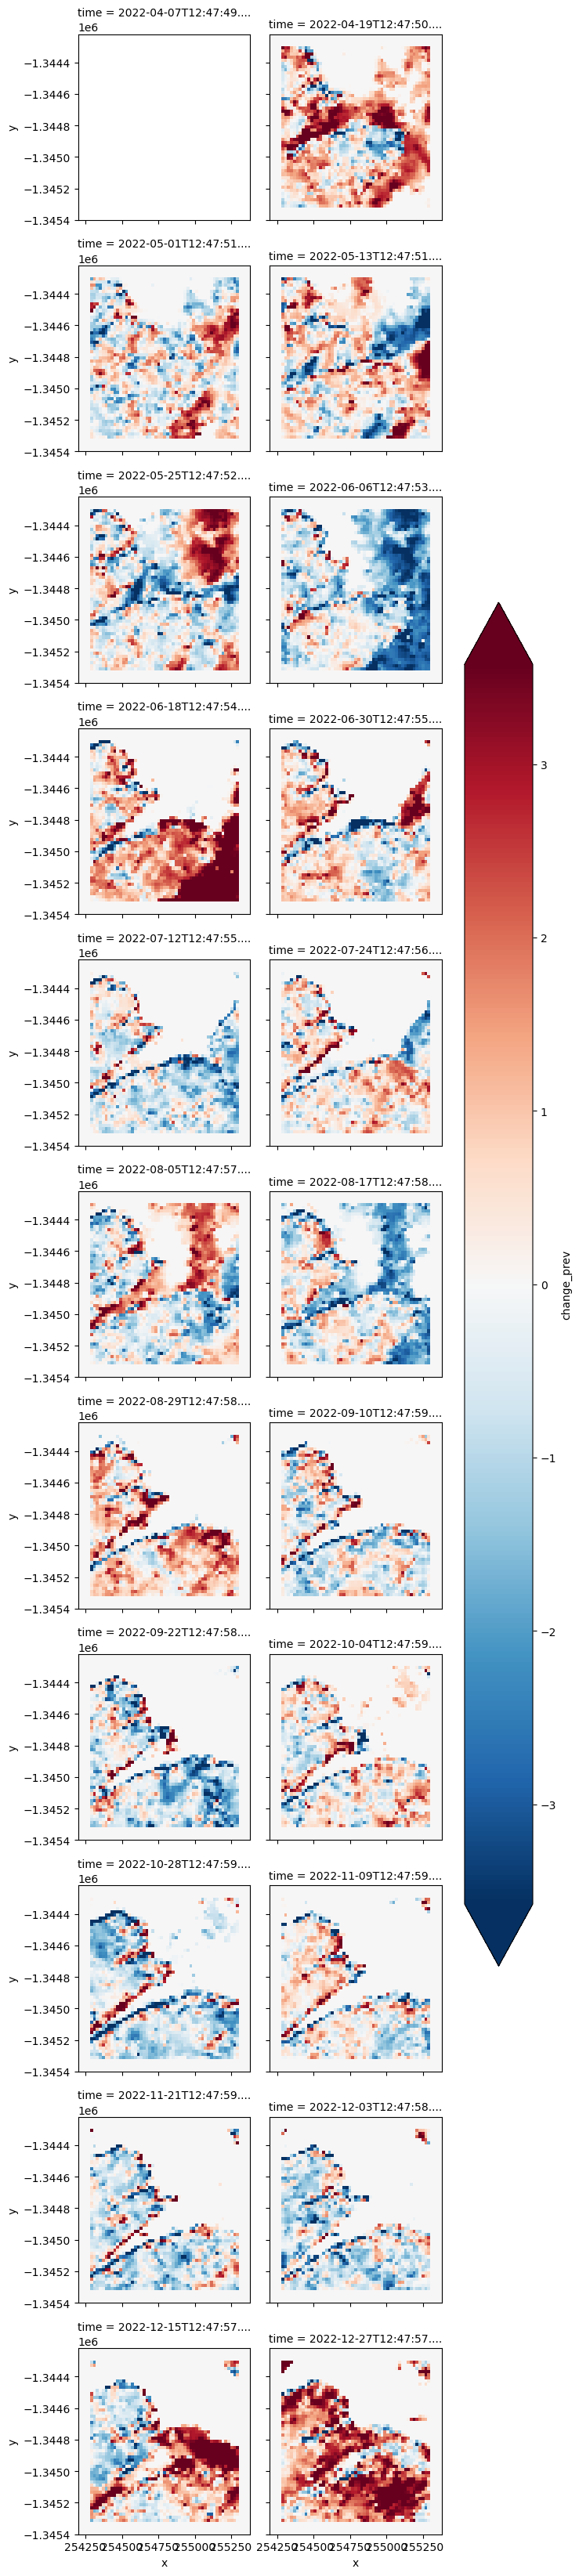

In [ ]:
# Compute change relative to previous time step
filtered_ds['change_prev'] = filtered_ds['HH_gamma0_lee_sigma_improved_dB_clipped'].diff(dim='time')

filtered_ds['change_prev'].plot.imshow(
    col="time",
    col_wrap=2,
    robust=True,
    cmap="RdBu_r"  # good for positive/negative changes
)


In [ ]:
filtered_ds.dims['time']

/tmp/ipykernel_3217/1548086358.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  filtered_ds.dims['time']


22

/tmp/ipykernel_3217/4130586803.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_times = filtered_ds.dims['time']


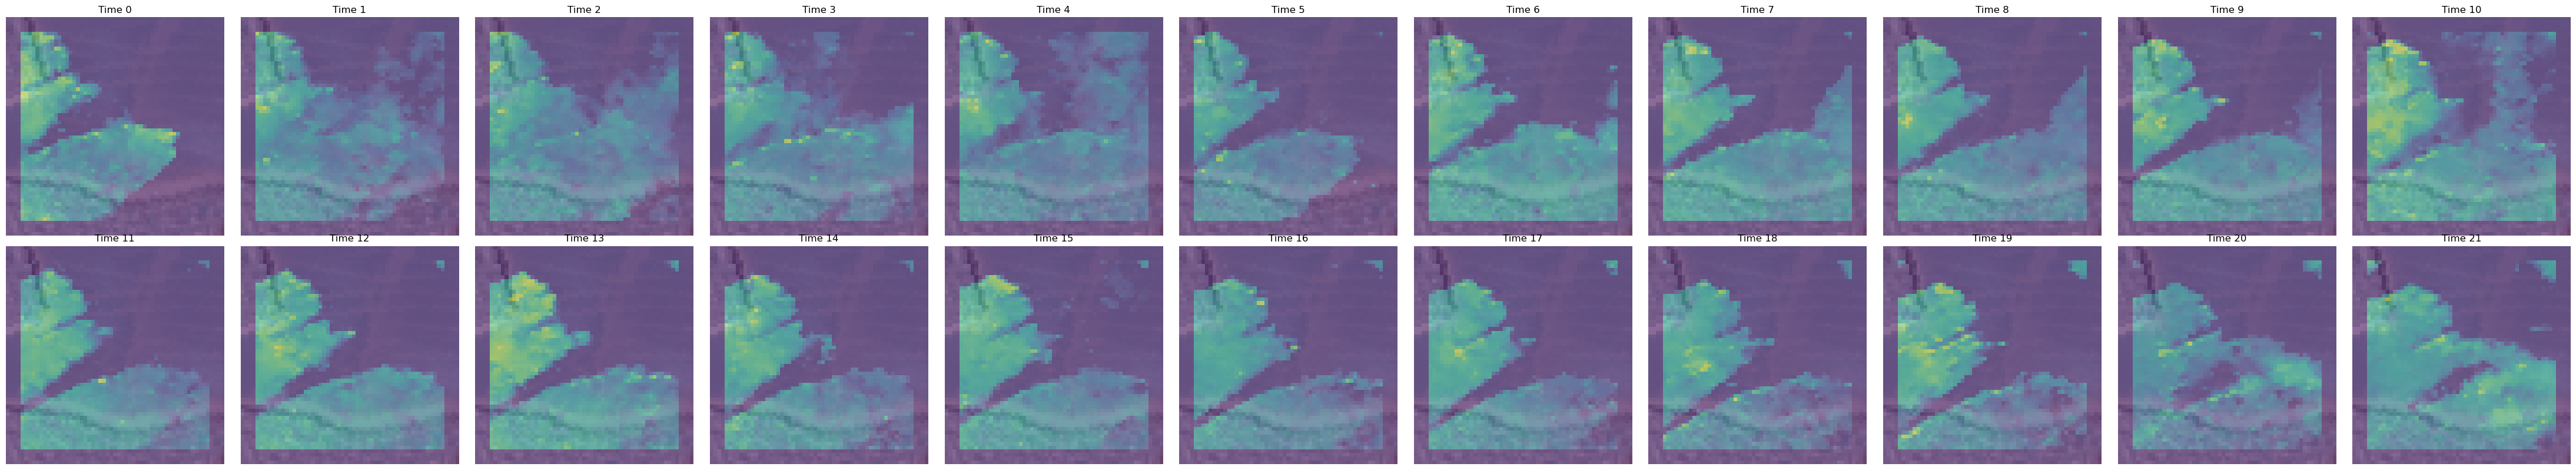

In [ ]:
n_times = filtered_ds.dims['time']
fig, axes = plt.subplots(nrows=2, ncols=round(n_times/2), figsize=(round(2*n_times),8))  # adjust layout

axes = axes.flatten()
for t in range(n_times):
      
    gamma0 = filtered_ds['HH_gamma0_lee_sigma_improved_dB_clipped'].isel(time=t)
    
    axes[t].imshow(rgb_S2, origin='upper')
    axes[t].imshow(gamma0, alpha=0.5, origin='upper')
    axes[t].set_title(f'Time {t}')
    axes[t].axis('off')

plt.tight_layout()
plt.show()
